## P69_73

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
import torch
import gymnasium as gym

import stable_pretraining as spt
import stable_worldmodel as swm
from torchvision.transforms import v2 as transforms
from sklearn.preprocessing import StandardScaler

import sys
sys.path.append('/home/stephen/Stephencwelch Dropbox/welch_labs/jepa_2/hackin/le-wm') #Path to cloned repo
from decoder import CLSDecoder

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

/home/stephen/Stephencwelch Dropbox/welch_labs/jepa_2/hackin/le-wm/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cpu


In [2]:
from __future__ import annotations
import numpy as np
import scipy.ndimage as ndi
 
 
def _hex(h: str) -> np.ndarray:
    h = h.lstrip("#")
    return np.array([int(h[i:i+2], 16) for i in (0, 2, 4)], dtype=np.float32)
 
 
# Welch Labs palette
CHILL_BROWN = _hex("#948979")
YELLOW      = _hex("#ffd35a")
YELLOW_FADE = _hex("#7f6a2d")
BLUE        = _hex("#00AEEF")
BLACK       = np.zeros(3, dtype=np.float32)
 

In [3]:
env = gym.make("swm/PushT-v1", render_mode="rgb_array")
obs, info = env.reset(seed=0)
print("action_space:", env.action_space)
print("frame:       ", env.render().shape, env.render().dtype)

action_space: Box(-1.0, 1.0, (2,), float32)
frame:        (224, 224, 3) uint8


In [4]:
ds = swm.data.HDF5Dataset(name="pusht_expert_train",
                          keys_to_cache=["action", "state"])

# --- action scaler (same as notebook 10) ---
all_actions = ds.get_col_data("action")
if all_actions.ndim == 3:
    all_actions_2d = all_actions.reshape(-1, all_actions.shape[-1])
else:
    all_actions_2d = all_actions
all_actions_2d = all_actions_2d[~np.isnan(all_actions_2d).any(axis=1)]
action_scaler = StandardScaler().fit(all_actions_2d)
print("action mean:", action_scaler.mean_)
print("action std: ", action_scaler.scale_)

06:55:27.598 | INFO    (3115744, stable_pretraining) | Cached 'action' from '/home/stephen/.stable_worldmodel/pusht_expert_train.h5'
06:55:27.616 | INFO    (3115744, stable_pretraining) | Cached 'state' from '/home/stephen/.stable_worldmodel/pusht_expert_train.h5'
action mean: [-0.00781256  0.00686069]
action std:  [0.20846744 0.20674863]


In [5]:
img_transform = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(**spt.data.dataset_stats.ImageNet),
    transforms.Resize(size=224),
])

# JEPA encoder + predictor + action_encoder bundled together
cost_model = swm.policy.AutoCostModel("pusht/lewm").to(DEVICE).eval()
# cost_model = swm.policy.AutoCostModel("from_lucas/lewm").to(DEVICE).eval()
cost_model.requires_grad_(False)
cost_model.interpolate_pos_encoding = True

encoder = cost_model.encoder.eval()
for p in encoder.parameters():
    p.requires_grad_(False)

# CLS-token decoder (ViT-S/14 patches → 224x224 RGB)
# decoder_weights = torch.load("from_lucas/decoder.pt", map_location=DEVICE)
# decoder_weights = torch.load("decoder_mc_10_epochs.pt", map_location=DEVICE)

#Path to Matthew's trained decoder
state_dict = torch.load('/home/stephen/Stephencwelch Dropbox/welch_labs/jepa_2/hackin/le-wm/decoder_mc_10_epochs.pt', weights_only=True, map_location=torch.device('cpu'))
#decoder = CLSDecoder(cls_dim=192, img_size=224, patch_size=14,
#                     dim=256, heads=8, depth=4)
decoder_mc = CLSDecoder(cls_dim=192, img_size=224, patch_size=14,
                     dim=256, heads=8, depth=3)
decoder_mc.load_state_dict(state_dict, strict=False)
# decoder_mc.load_state_dict(decoder_weights)
decoder_mc = decoder_mc.to(DEVICE).eval()
decoder_mc.requires_grad_(False);

In [6]:
import torch.nn as nn

enc_dim  = cost_model.encoder.config.hidden_size
proj_dim = 192

# Load the trained adapter model
adapter_state_dict = torch.load('/home/stephen/Stephencwelch Dropbox/welch_labs/jepa_2/hackin/le-wm/adapter_weights.pt', weights_only=True, map_location=torch.device('cpu'))

adapter = nn.Sequential(
    nn.Linear(proj_dim, 512),
    nn.GELU(),
    nn.Linear(512, enc_dim),
)

adapter.load_state_dict(adapter_state_dict, strict=False)
adapter = adapter.to(DEVICE).eval()
adapter.requires_grad_(False);

In [7]:
@torch.no_grad()
def encode_frame(rgb_uint8, cost_model, transform, device):
    """(H, W, 3) uint8 -> (1, D) projected emb."""
    px = transform(rgb_uint8).unsqueeze(0).unsqueeze(0).to(device)  # (1, 1, 3, H, W)
    info = {"pixels": px}
    info = cost_model.encode(info)
    return info["emb"][:, 0]   # (1, T=1, D) -> (1, D)


@torch.no_grad()
def decode_emb(emb_1d, adapter, decoder):
    """(1, D) projected emb -> (H, W, 3) float [0,1] for imshow."""
    cls_hat = adapter(emb_1d)                              # (1, enc_dim)
    img = decoder(cls_hat)[0].detach().permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img


def pack_action_block(actions_5x2, action_scaler, device):
    """(5, 2) env-scale actions -> (1, 10) standardized tensor."""
    a = np.asarray(actions_5x2, dtype=np.float32)
    assert a.shape == (5, 2), f"expected (5, 2), got {a.shape}"
    a_std = action_scaler.transform(a).astype(np.float32)  # (5, 2)
    a_flat = a_std.reshape(-1)                             # (10,)
    return torch.from_numpy(a_flat).to(device).unsqueeze(0)  # (1, 10)


@torch.no_grad()
def predict_next(cost_model, emb_hist, act_hist, history_size=3):
    """
    emb_hist: list of (1, D) tensors — projected embeddings.
    act_hist: list of (1, 10) tensors — packed action blocks.
    Returns: (1, D) next projected embedding.
    """
    assert len(emb_hist) == len(act_hist), (
        f"history mismatch: {len(emb_hist)} embs vs {len(act_hist)} acts"
    )
    HS = history_size
    emb_seq = torch.stack(emb_hist[-HS:], dim=1)    # (1, L, D)
    act_seq = torch.stack(act_hist[-HS:], dim=1)    # (1, L, 10)
    act_emb = cost_model.action_encoder(act_seq)    # (1, L, A_emb)
    pred    = cost_model.predict(emb_seq, act_emb)  # (1, L, D)
    return pred[:, -1]                              # (1, D)


@torch.no_grad()
def play_game_v2(actions_5x2, cost_model, decoder, adapter, scaler,
              act_hist, emb_hist, frames, titles, device):
    # 1) pack action — store as (1, 10)
    a_block = pack_action_block(actions_5x2, scaler, device)  # (1, 10)
    act_hist.append(a_block)

    # 2) predict next projected embedding
    next_emb = predict_next(cost_model, emb_hist, act_hist, history_size=3)  # (1, D)
    emb_hist.append(next_emb)

    # 3) adapter -> decoder
    img = decode_emb(next_emb, adapter, decoder)
    frames.append(img)
    titles.append(f"t={(len(frames)-1)*5} (decoded)")

    show_strip(frames, titles)
    return next_emb, act_hist, emb_hist, frames, titles


def show_strip(frames, titles=None, figsize_per=2.2):
    """Plot a horizontal strip of frames."""
    n = len(frames)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per * n, figsize_per))
    if n == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.imshow(frames[i])
        ax.axis("off")
        if titles is not None:
            ax.set_title(titles[i], fontsize=9)
    plt.tight_layout()
    plt.show()


def show_images(original, recon, titles=None, figsize_per=2.2):
    fig, axes = plt.subplots(1, 2, figsize=(figsize_per * 2, figsize_per))
    
    # Display images on specific axes
    axes[0].imshow(original)
    axes[0].set_title("Original")

    axes[1].imshow(recon)
    axes[1].set_title("Reconstructed")
    
    plt.tight_layout()
    plt.show()

In [8]:
DEFAULT_PALETTE: dict = {
    # ── source anchors (sampled by hand from the PushT renderer) ─────────
    "src_bg":            np.array([254, 254, 254], dtype=np.float32),
    "src_frame_border":  np.array([197,	197,	197		], dtype=np.float32),
    "src_target_fill":   np.array([91,	229,	104	], dtype=np.float32),  # green T
    "src_movable_fill":  np.array([92,	121,	147	], dtype=np.float32),  # blue-gray T
    "src_effector_fill": np.array([11,	78,	248	], dtype=np.float32),  # blue dot
    "src_target_outline":   np.array([104,	231,	115	], dtype=np.float32),  # green T
    "src_movable_outline":  np.array([64,	85,	106	], dtype=np.float32),  # blue-gray T
    "src_effector_outline": np.array([11,	65,	212	], dtype=np.float32),  # blue dot
    
    # ── target colors ────────────────────────────────────────────────────
    "tgt_bg":               BLACK,
    "tgt_frame_border":     BLACK,
    "tgt_target_fill":      CHILL_BROWN,
    "tgt_target_outline":   CHILL_BROWN, # * 0.55,
    "tgt_movable_fill":     BLUE,
    "tgt_movable_outline":  BLUE * 0.75,
    "tgt_effector_fill":    YELLOW,
    "tgt_effector_outline": YELLOW,
 
    # ── fill-mask thresholds (loose color-ball radii) ────────────────────
    # Only used to seed the Voronoi label propagation; doesn't need to be tight.
    "r_target_fill":   45.0,
    "r_movable_fill":  22.0,
    "r_effector_fill": 55.0,
 
    # ── connected-component cleanup ──────────────────────────────────────
    # Drop fill-mask components smaller than this many pixels (kills stray AA
    # pixels that happen to fall inside a fill color ball).
    "min_component_size": 10,
}
 


DECODED_PALETTE: dict = {
    # ── source anchors (sampled by hand from the PushT renderer) ─────────
    "src_bg":            np.array([203,	214,	226	], dtype=np.float32),
    "src_frame_border":  np.array([156,	164,	178	], dtype=np.float32),
    # "src_target_fill":   np.array([64,	184,	93	], dtype=np.float32),  # green T
    "src_target_fill":   np.array([88,	201,	112	], dtype=np.float32),  # green T
    
    # "src_movable_fill":  np.array([69,	100,	137	], dtype=np.float32),  # blue-gray T
    "src_movable_fill":  np.array([92,	121,	147	], dtype=np.float32),  # blue-gray T

    "src_effector_fill": np.array([ 15,	69,	215	], dtype=np.float32),  # blue dot
    "src_target_outline":   np.array([87,	172,	115	], dtype=np.float32),  # green T
    "src_movable_outline":  np.array([53,	77,	103	], dtype=np.float32),  # blue-gray T
    "src_effector_outline": np.array([14,	61,	175	], dtype=np.float32),  # blue dot
 
    # ── target colors ────────────────────────────────────────────────────
    "tgt_bg":               BLACK,
    "tgt_frame_border":     BLACK,
    "tgt_target_fill":      CHILL_BROWN,
    "tgt_target_outline":   CHILL_BROWN, # * 0.55,
    "tgt_movable_fill":     BLUE,
    "tgt_movable_outline":  BLUE * 0.75,
    "tgt_effector_fill":    YELLOW,
    "tgt_effector_outline": YELLOW,
 
    # ── fill-mask thresholds (loose color-ball radii) ────────────────────
    # Only used to seed the Voronoi label propagation; doesn't need to be tight.
    "r_target_fill":   45.0,
    "r_movable_fill":  22.0,
    "r_effector_fill": 55.0,
 
    # ── connected-component cleanup ──────────────────────────────────────
    # Drop fill-mask components smaller than this many pixels (kills stray AA
    # pixels that happen to fall inside a fill color ball).
    "min_component_size": 10,
}
 
 
# Per-shape (label_id, fill_src_key, outline_src_key, fill_tgt_key, outline_tgt_key)
_SHAPES = [
    (1, "src_target_fill",   "src_target_outline",   "tgt_target_fill",   "tgt_target_outline"),
    (2, "src_movable_fill",  "src_movable_outline",  "tgt_movable_fill",  "tgt_movable_outline"),
    (3, "src_effector_fill", "src_effector_outline", "tgt_effector_fill", "tgt_effector_outline"),
]
 
 
def _keep_largest_components(mask: np.ndarray, min_size: int) -> np.ndarray:
    """Drop connected components smaller than min_size pixels."""
    lab, n = ndi.label(mask)
    if n == 0:
        return mask
    sizes = ndi.sum_labels(mask, lab, range(1, n + 1))
    keep = np.zeros(n + 1, dtype=bool)
    keep[1:] = sizes >= min_size
    return keep[lab]
 
 
def _segment_shapes(img: np.ndarray, p: dict) -> np.ndarray:
    """Per-pixel shape label via threshold + cleanup + Voronoi propagation."""
    def ball(anchor, r):
        return np.linalg.norm(img - anchor, axis=-1) < r
 
    min_sz = int(p["min_component_size"])
    labels = np.zeros(img.shape[:2], dtype=np.int32)
    labels[_keep_largest_components(ball(p["src_target_fill"],   p["r_target_fill"]),   min_sz)] = 1
    labels[_keep_largest_components(ball(p["src_movable_fill"],  p["r_movable_fill"]),  min_sz)] = 2
    labels[_keep_largest_components(ball(p["src_effector_fill"], p["r_effector_fill"]), min_sz)] = 3
 
    if (labels == 0).all():
        # Pure-background frame; return zeros — output will be BLACK everywhere via bg anchor.
        return labels
 
    _, idx = ndi.distance_transform_edt(labels == 0, return_indices=True)
    return labels[idx[0], idx[1]]
 
 
def recolor_pusht(
    frame: np.ndarray,
    palette: dict | None = None,
    sigma: float = 22.0,
) -> np.ndarray:
    """Recolor one PushT frame.
 
    Args:
        frame:   (H, W, 3) uint8 RGB array.
        palette: dict matching DEFAULT_PALETTE structure (or None for defaults).
        sigma:   Gaussian σ in RGB units. 12 = very crisp, 22 = default, 35 = soft.
 
    Returns:
        (H, W, 3) uint8 RGB array.
    """
    p = palette if palette is not None else DEFAULT_PALETTE
    img = frame.astype(np.float32)
    H, W, _ = img.shape
 
    # 1. Spatial label per pixel
    lbl = _segment_shapes(img, p)
 
    # 2. Per-pixel fill/outline anchors based on shape label
    src_fill_pp    = np.empty_like(img)
    src_outline_pp = np.empty_like(img)
    tgt_fill_pp    = np.empty_like(img)
    tgt_outline_pp = np.empty_like(img)
    for lbl_val, sf_key, so_key, tf_key, to_key in _SHAPES:
        m = (lbl == lbl_val)
        if not m.any():
            continue
        src_fill_pp[m]    = p[sf_key]
        src_outline_pp[m] = p[so_key]
        tgt_fill_pp[m]    = p[tf_key]
        tgt_outline_pp[m] = p[to_key]
 
    # Fallback: if no shape was detected anywhere, point the shape anchors at bg
    # so they don't contribute spurious color via uninitialized memory.
    if (lbl == 0).any():
        src_fill_pp[lbl == 0]    = p["src_bg"]
        src_outline_pp[lbl == 0] = p["src_bg"]
        tgt_fill_pp[lbl == 0]    = p["tgt_bg"]
        tgt_outline_pp[lbl == 0] = p["tgt_bg"]
 
    # 3. Global bg + frame_border anchors broadcast to per-pixel shape
    bg_src    = np.broadcast_to(p["src_bg"],           img.shape)
    bg_tgt    = np.broadcast_to(p["tgt_bg"],           img.shape)
    frame_src = np.broadcast_to(p["src_frame_border"], img.shape)
    frame_tgt = np.broadcast_to(p["tgt_frame_border"], img.shape)
 
    src_pp = np.stack([src_fill_pp, src_outline_pp, bg_src, frame_src], axis=-2)  # (H, W, 4, 3)
    tgt_pp = np.stack([tgt_fill_pp, tgt_outline_pp, bg_tgt, frame_tgt], axis=-2)
 
    # 4. Gaussian soft blend over the 4 anchors
    d2 = ((img[..., None, :] - src_pp) ** 2).sum(-1)            # (H, W, 4)
    w  = np.exp(-d2 / (2.0 * sigma * sigma))
    w /= w.sum(-1, keepdims=True)
    out = (w[..., None] * tgt_pp).sum(-2)                        # (H, W, 3)
 
    return np.clip(out, 0, 255).astype(np.uint8)

## Play Video Game

In [9]:
from PIL import Image

save_dir='/home/stephen/Stephencwelch Dropbox/welch_labs/jepa_2/hackin/p69'

## Move Left

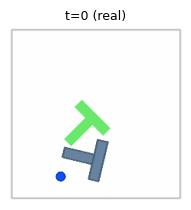

In [10]:
# fresh env just to get a deterministic starting frame matched to Part A's seed=0 reset.
env_game = gym.make("swm/PushT-v1", render_mode="rgb_array")
env_game.reset(seed=2)
start_frame = env_game.render()
env_game.close()

# Initialise histories with the first observed frame
first_emb = encode_frame(start_frame, cost_model=cost_model, transform=img_transform, device=DEVICE)  # (1, D)
emb_hist = [first_emb]
act_hist = []

# Seed frames with the real observation for visual reference
frames = [((start_frame - start_frame.min()) / (start_frame.max() - start_frame.min() + 1e-8))]
titles = ["t=0 (real)"]

show_strip(frames, titles)

In [11]:
img_r=recolor_pusht(np.round(frames[0]*255).astype('uint8'), palette=DEFAULT_PALETTE, sigma=45)

Image.fromarray(img_r).save(save_dir+'/start.png')

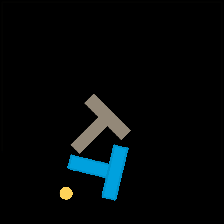

In [12]:
Image.fromarray(img_r)

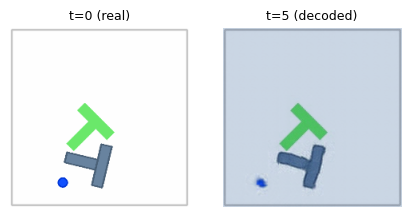

In [13]:
actions = np.array([
    [-0.2, 0.0],
    [-0.2, 0.0],
    [-0.2, 0.0],
    [-0.2, 0.0],
    [-0.2, 0.0], #LEFT
], dtype=np.float32) 

# _ = play_game(actions)
next_emb, act_hist, emb_hist, frames, titles = play_game_v2(
    actions_5x2=actions,
    cost_model=cost_model,
    decoder=decoder_mc,
    adapter=adapter,
    scaler=action_scaler,
    act_hist=act_hist,
    emb_hist=emb_hist,
    frames=frames,
    titles=titles,
    device=DEVICE
)

In [14]:
len(frames)

2

In [15]:
frames[1].shape

(224, 224, 3)

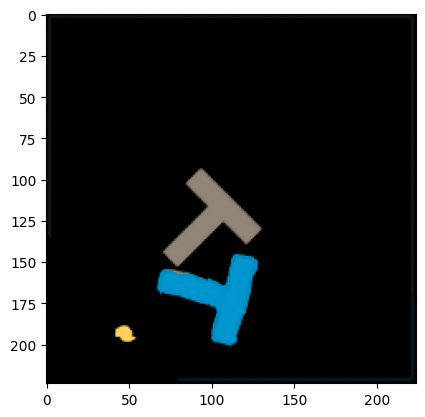

In [16]:
img_r=recolor_pusht(np.round(frames[1]*255).astype('uint8'), palette=DECODED_PALETTE, sigma=45) 
plt.imshow(img_r)

In [17]:
Image.fromarray(img_r).save(save_dir+'/move_left.png')

In [18]:
emb_hist_np=np.array([o.cpu().numpy().ravel() for o in emb_hist])
np.save(save_dir+'/move_left', emb_hist_np)

In [19]:
emb_hist_np.shape

(2, 192)

## Move Right

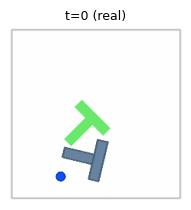

In [20]:
# fresh env just to get a deterministic starting frame matched to Part A's seed=0 reset.
env_game = gym.make("swm/PushT-v1", render_mode="rgb_array")
env_game.reset(seed=2)
start_frame = env_game.render()
env_game.close()

# Initialise histories with the first observed frame
first_emb = encode_frame(start_frame, cost_model=cost_model, transform=img_transform, device=DEVICE)  # (1, D)
emb_hist = [first_emb]
act_hist = []

# Seed frames with the real observation for visual reference
frames = [((start_frame - start_frame.min()) / (start_frame.max() - start_frame.min() + 1e-8))]
titles = ["t=0 (real)"]

show_strip(frames, titles)

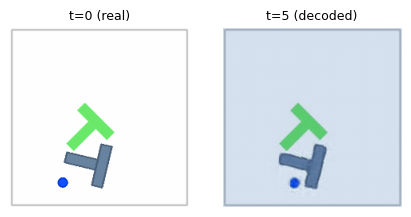

In [21]:
actions = np.array([
    [0.2, 0.0],
    [0.2, 0.0],
    [0.2, 0.0],
    [0.2, 0.0],
    [0.2, 0.0], 
], dtype=np.float32) 

# _ = play_game(actions)
next_emb, act_hist, emb_hist, frames, titles = play_game_v2(
    actions_5x2=actions,
    cost_model=cost_model,
    decoder=decoder_mc,
    adapter=adapter,
    scaler=action_scaler,
    act_hist=act_hist,
    emb_hist=emb_hist,
    frames=frames,
    titles=titles,
    device=DEVICE
)

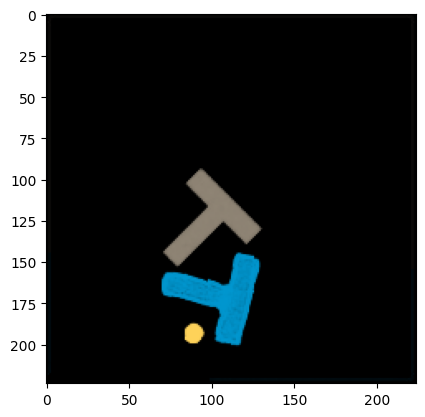

In [22]:
img_r=recolor_pusht(np.round(frames[1]*255).astype('uint8'), palette=DECODED_PALETTE, sigma=45) 
Image.fromarray(img_r).save(save_dir+'/move_right.png')
plt.imshow(img_r)

In [23]:
emb_hist_np=np.array([o.cpu().numpy().ravel() for o in emb_hist])
np.save(save_dir+'/move_right', emb_hist_np)

## Move Up

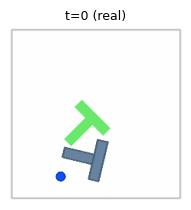

In [24]:
# fresh env just to get a deterministic starting frame matched to Part A's seed=0 reset.
env_game = gym.make("swm/PushT-v1", render_mode="rgb_array")
env_game.reset(seed=2)
start_frame = env_game.render()
env_game.close()

# Initialise histories with the first observed frame
first_emb = encode_frame(start_frame, cost_model=cost_model, transform=img_transform, device=DEVICE)  # (1, D)
emb_hist = [first_emb]
act_hist = []

# Seed frames with the real observation for visual reference
frames = [((start_frame - start_frame.min()) / (start_frame.max() - start_frame.min() + 1e-8))]
titles = ["t=0 (real)"]

show_strip(frames, titles)

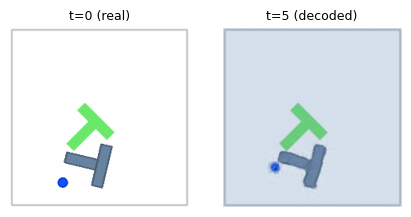

In [25]:
actions = np.array([
    [0.0, -0.2],
    [0.0, -0.2],
    [0.0, -0.2],
    [0.0, -0.2],
    [0.0, -0.2], 
], dtype=np.float32) 

# _ = play_game(actions)
next_emb, act_hist, emb_hist, frames, titles = play_game_v2(
    actions_5x2=actions,
    cost_model=cost_model,
    decoder=decoder_mc,
    adapter=adapter,
    scaler=action_scaler,
    act_hist=act_hist,
    emb_hist=emb_hist,
    frames=frames,
    titles=titles,
    device=DEVICE
)

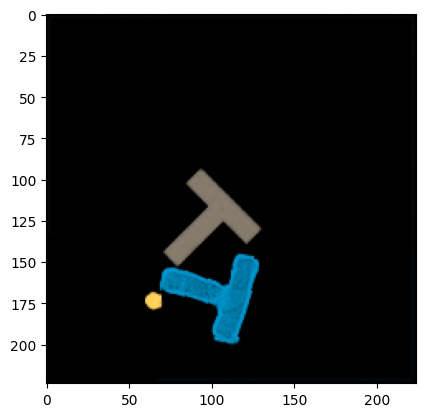

In [26]:
img_r=recolor_pusht(np.round(frames[1]*255).astype('uint8'), palette=DECODED_PALETTE, sigma=45) 
Image.fromarray(img_r).save(save_dir+'/move_up.png')
plt.imshow(img_r)

Hmm why is my color mapping not working on up?

In [27]:
emb_hist_np=np.array([o.cpu().numpy().ravel() for o in emb_hist])
np.save(save_dir+'/move_up', emb_hist_np)

## Move Down

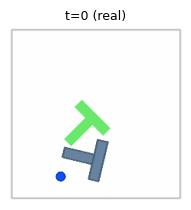

In [28]:
# fresh env just to get a deterministic starting frame matched to Part A's seed=0 reset.
env_game = gym.make("swm/PushT-v1", render_mode="rgb_array")
env_game.reset(seed=2)
start_frame = env_game.render()
env_game.close()

# Initialise histories with the first observed frame
first_emb = encode_frame(start_frame, cost_model=cost_model, transform=img_transform, device=DEVICE)  # (1, D)
emb_hist = [first_emb]
act_hist = []

# Seed frames with the real observation for visual reference
frames = [((start_frame - start_frame.min()) / (start_frame.max() - start_frame.min() + 1e-8))]
titles = ["t=0 (real)"]

show_strip(frames, titles)

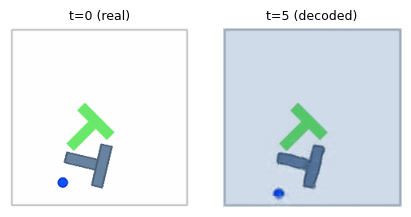

In [29]:
actions = np.array([
    [0.0, 0.15],
    [0.0, 0.15],
    [0.0, 0.15],
    [0.0, 0.15],
    [0.0, 0.15], 
], dtype=np.float32) 

# _ = play_game(actions)
next_emb, act_hist, emb_hist, frames, titles = play_game_v2(
    actions_5x2=actions,
    cost_model=cost_model,
    decoder=decoder_mc,
    adapter=adapter,
    scaler=action_scaler,
    act_hist=act_hist,
    emb_hist=emb_hist,
    frames=frames,
    titles=titles,
    device=DEVICE
)

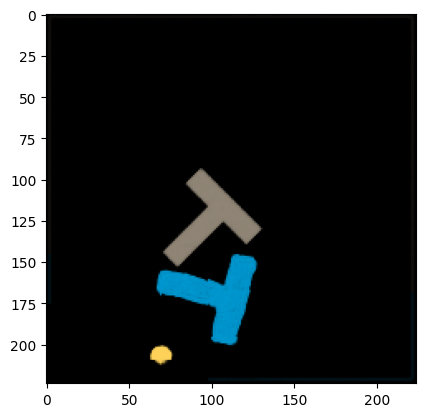

In [30]:
img_r=recolor_pusht(np.round(frames[1]*255).astype('uint8'), palette=DECODED_PALETTE, sigma=45) 
Image.fromarray(img_r).save(save_dir+'/move_down.png')
plt.imshow(img_r)

In [31]:
emb_hist_np=np.array([o.cpu().numpy().ravel() for o in emb_hist])
np.save(save_dir+'/move_down', emb_hist_np)

## P71
- Ok I think it makes sense to stick with the same notebook for now!
- Ok so the whole thing here is comparing real rollouts to world model ones
- This section is probably a pretty good fit for Claude
- Due to action blocking, I think I can only show every 5th step - which is fine
- So I think for p71, I use the same expert trajectories
- And for both the simulated and real environments, for each expert trajectory I need to render: starting frame, every 5th frame, save all actions as npz, save all embeddings as npz. 

---

In [32]:
len(emb_hist)

2

In [33]:
emb_hist[0].shape

torch.Size([1, 192])

In [34]:
emb_hist[1].shape

torch.Size([1, 192])

In [35]:
act_hist

[tensor([[0.0375, 0.6923, 0.0375, 0.6923, 0.0375, 0.6923, 0.0375, 0.6923, 0.0375,
          0.6923]])]

In [36]:
next_emb.shape

torch.Size([1, 192])

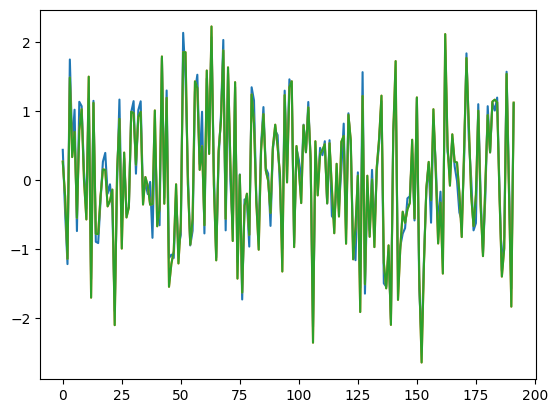

In [37]:
plt.plot(emb_hist[0].detach().cpu().numpy().ravel())
plt.plot(emb_hist[1].detach().cpu().numpy().ravel())
plt.plot(next_emb.detach().cpu().numpy().ravel())

In [38]:
# cost_model